# Plots with GOL

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

try:
    import srxraylib.plot.gol as _gol
    _gol.set_qt = lambda: None
except Exception:
    pass


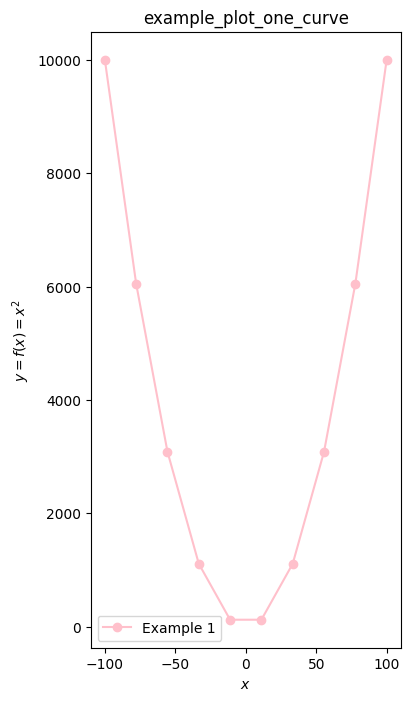

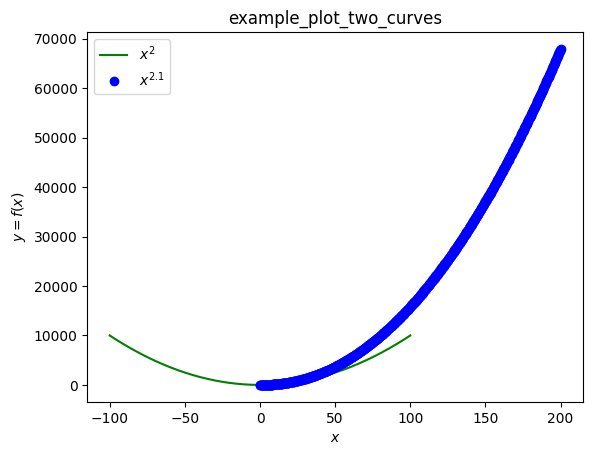

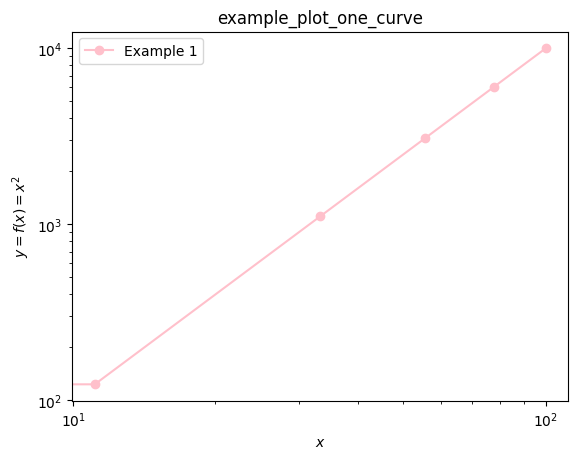

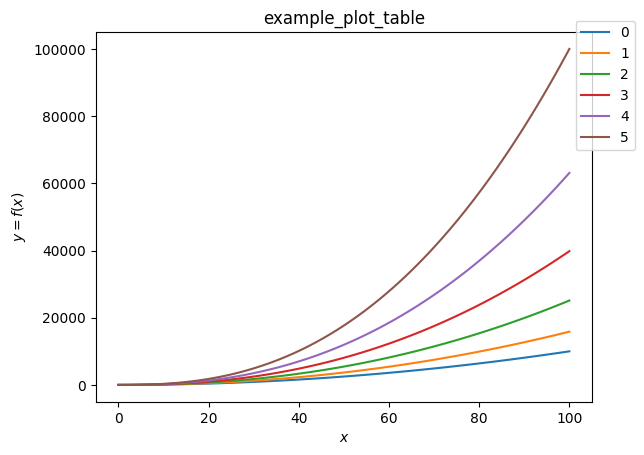

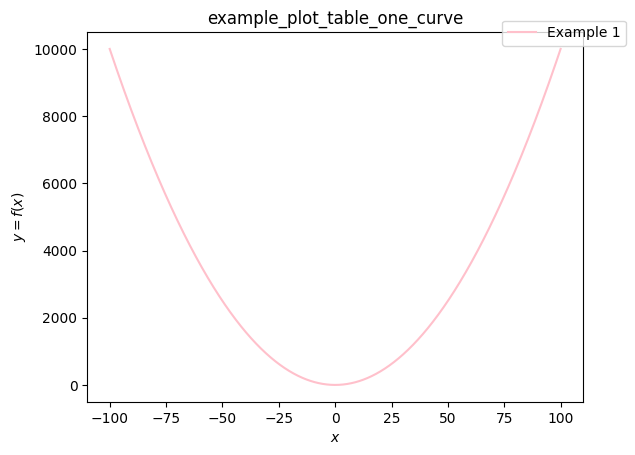

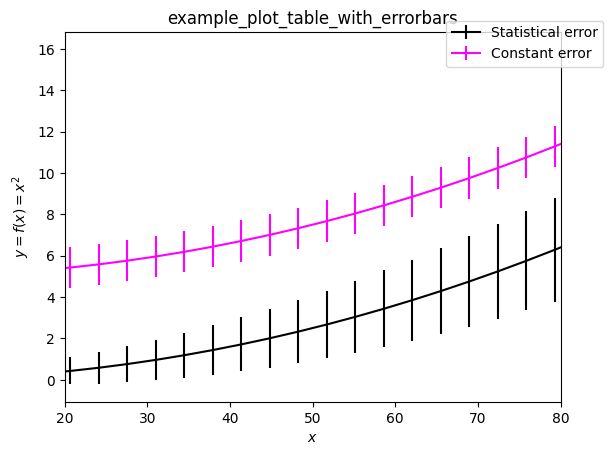

Size 8100 pixels


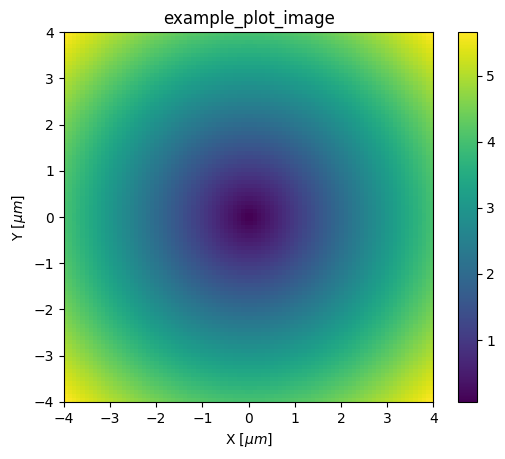

Size 18000 pixels


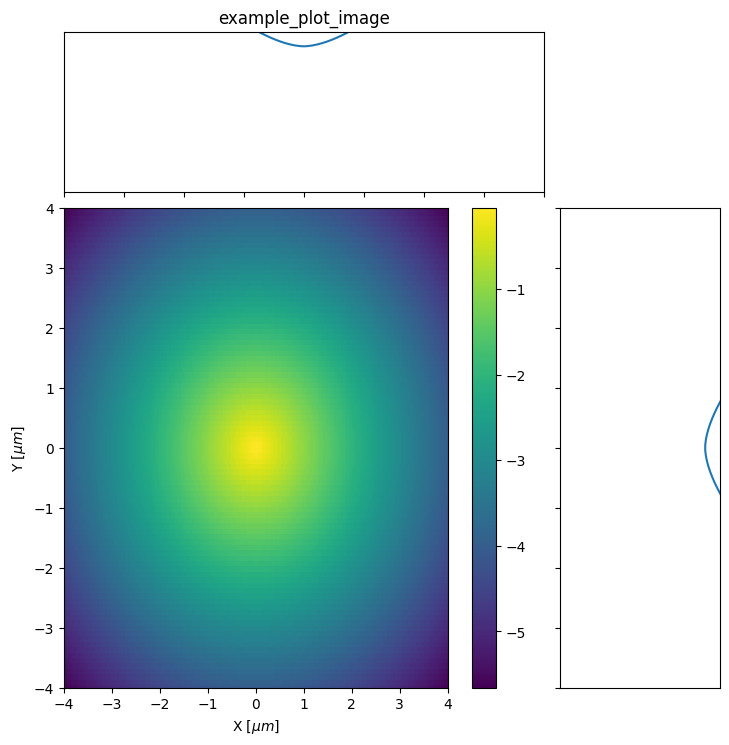

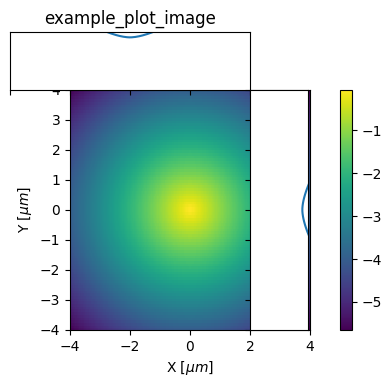

Size 400 pixels
(20, 20) (20, 20) (20, 20)


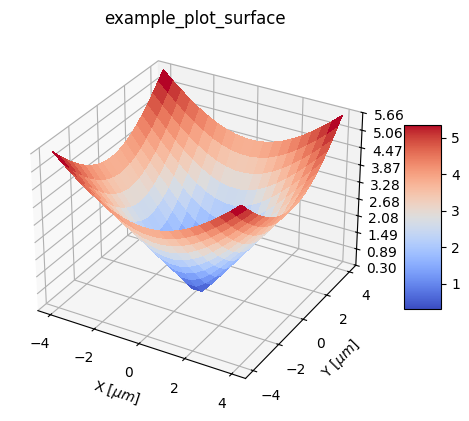

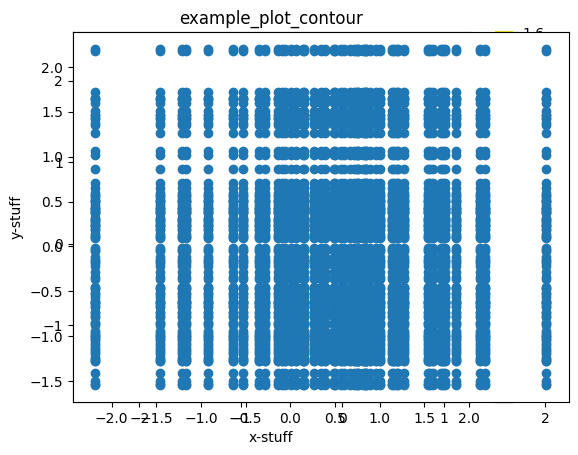

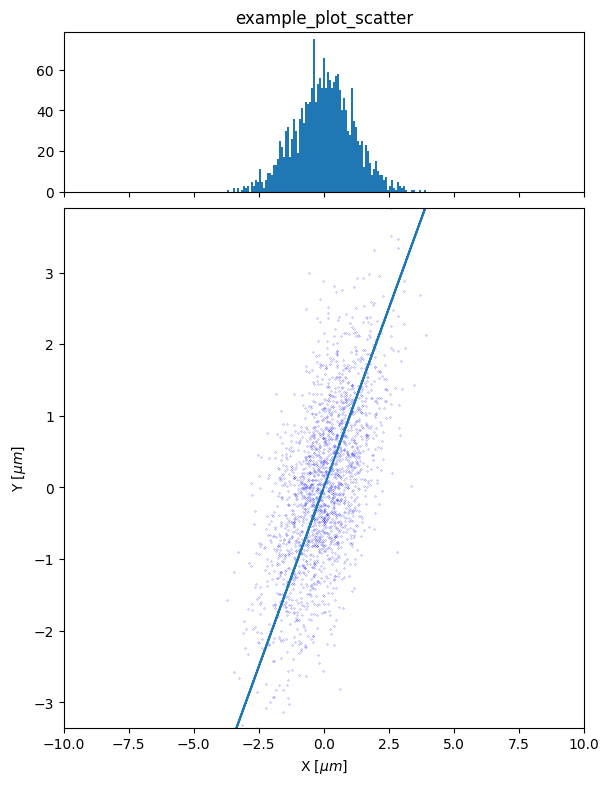

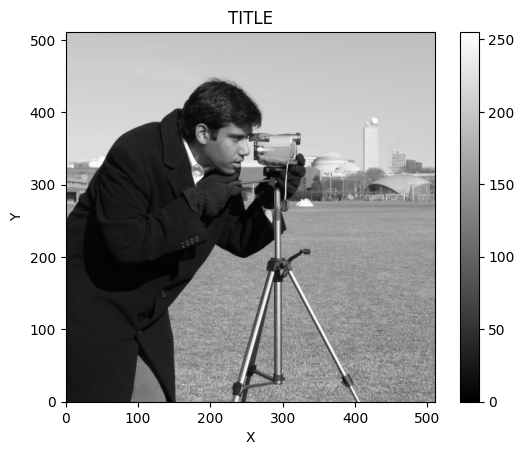

In [2]:
"""
Examples of using the GOL plotting functions.
"""
import numpy as np
from srxraylib.plot.gol import *

def example_plot_image():
    x = np.linspace(-4, 4, 90)
    y = np.linspace(-4, 4, 90)
    print('Size %d pixels' % (len(x) * len(y)))
    z = np.sqrt(x[np.newaxis, :]**2 + y[:, np.newaxis]**2)
    plot_image(z,x,y,title="example_plot_image",xtitle=r"X [$\mu m$]",ytitle=r"Y [$\mu m$]",cmap=None,show=1)

def example_plot_image_with_histograms():
    x = np.linspace(-4, 4, 200)
    y = np.linspace(-4, 4, 90)
    print('Size %d pixels' % (len(x) * len(y)))
    z = -np.sqrt(x[np.newaxis, :]**2 + y[:, np.newaxis]**2)
    plot_image_with_histograms(z.T,x,y,title="example_plot_image",xtitle=r"X [$\mu m$]",ytitle=r"Y [$\mu m$]",
                               cmap=None,show=1,figsize=(8,8),add_colorbar=True)

    plot_image_with_histograms(z.T, x, y, title="example_plot_image", xtitle=r"X [$\mu m$]", ytitle=r"Y [$\mu m$]",
                               cmap=None, show=1, figsize=(10,4), aspect='equal', add_colorbar=True)

def example_plot_surface():
    x = np.linspace(-4, 4, 20)
    y = np.linspace(-4, 4, 20)
    print('Size %d pixels' % (len(x) * len(y)))
    z = np.sqrt(x[np.newaxis, :]**2 + y[:, np.newaxis]**2)
    plot_surface(z,x,y,title="example_plot_surface",xtitle=r"X [$\mu m$]",ytitle=r"Y [$\mu m$]",cmap=None,show=1)

def example_plot_scatter():
    #example motivated by http://www.ster.kuleuven.be/~pieterd/python/html/core/scipystats.html
    from scipy import stats
    # x = np.random.rand(1000)
    # y = np.random.rand(1000)
    x = stats.norm.rvs(size=2000)
    y = stats.norm.rvs(scale=0.5, size=2000)
    data = np.vstack([x+y, x-y])
    f = plot_scatter(data[0],data[1],xrange=[-10,10],title="example_plot_scatter",
                     xtitle=r"X [$\mu m$]",ytitle=r"Y [$\mu m$]",plot_histograms=2,show=0)
    f[1].plot(data[0],data[0]) # use directly matplotlib to overplot
    plot_show()

def example_plot_contour():
    # deprecated in matplotlib. Copied from" https://github.com/matplotlib/matplotlib/blob/81e8154dbba54ac1607b21b22984cabf7a6598fa/lib/matplotlib/mlab.py#L1866
    def bivariate_normal(X, Y, sigmax=1.0, sigmay=1.0,
                         mux=0.0, muy=0.0, sigmaxy=0.0):
        """
        Bivariate Gaussian distribution for equal shape *X*, *Y*.
        See `bivariate normal
        <http://mathworld.wolfram.com/BivariateNormalDistribution.html>`_
        at mathworld.
        """
        Xmu = X - mux
        Ymu = Y - muy

        rho = sigmaxy / (sigmax * sigmay)
        z = Xmu ** 2 / sigmax ** 2 + Ymu ** 2 / sigmay ** 2 - 2 * rho * Xmu * Ymu / (sigmax * sigmay)
        denom = 2 * np.pi * sigmax * sigmay * np.sqrt(1 - rho ** 2)
        return np.exp(-z / (2 * (1 - rho ** 2))) / denom

    # inspired by http://stackoverflow.com/questions/10291221/axis-limits-for-scatter-plot-not-holding-in-matplotlib
    # random data
    x = np.random.randn(50)
    y = np.random.randn(100)

    X, Y = np.meshgrid(y, x)
    Z1 = bivariate_normal(X, Y, 1.0, 1.0, 0.0, 0.0)
    Z2 = bivariate_normal(X, Y, 1.5, 0.5, 1, 1)
    Z = 10 * (Z1 - Z2)

    plot_contour(Z,x,y,title='example_plot_contour',xtitle='x-stuff',ytitle='y-stuff',plot_points=1,show=1)

def example_plot_one_curve():
    x = np.linspace(-100,100,10)
    y = x**2
    plot(x,y,xtitle=r'$x$',title="example_plot_one_curve",
         ytitle=r'$y=f(x)=x^2$',legend="Example 1",color='pink',marker='o',linestyle=None,
         figsize=(4,8),show=1)

def example_plot_one_curve_log():
    x = np.linspace(-100,100,10)
    y = x**2
    plot(x,y,xtitle=r'$x$',title="example_plot_one_curve",
         ytitle=r'$y=f(x)=x^2$',legend="Example 1",color='pink',marker='o',linestyle=None,xlog=1,ylog=1,show=1)

def example_plot_two_curves():
    x1 = np.linspace(-100,100,1000)
    y1 = x1**2
    x2 = np.linspace(0,200,700)
    y2 = x2**2.1
    plot(x1,y1,x2,y2,xtitle=r'$x$',title="example_plot_two_curves",
         ytitle=r'$y=f(x)$',legend=[r"$x^2$",r"$x^{2.1}$"],color=['green','blue'],marker=[' ','o'],linestyle=['-',' '],show=1)

def example_plot_table():
    x1 = np.linspace(0,100,100)
    out = np.zeros((6,x1.size))
    out[0,:] = x1**2
    out[1,:] = x1**2.1
    out[2,:] = x1**2.2
    out[3,:] = x1**2.3
    out[4,:] = x1**2.4
    out[5,:] = x1**2.5
    # another way
    # out = np.vstack( (
    #     x1**2,
    #     x1**2.1,
    #     x1**2.2,
    #     x1**2.3,
    #     x1**2.4,
    #     x1**2.5 ))
    legend=np.arange(out.shape[0]).astype("str")
    plot_table(x1,out,xtitle=r'$x$',ytitle=r'$y=f(x)$',title="example_plot_table",legend=legend,show=1)

def example_plot_table_one_curve():
    x1 = np.linspace(-100,100,1000)
    out = x1**2
    plot_table(x1,out,title="example_plot_table_one_curve",xtitle=r'$x$',ytitle=r'$y=f(x)$',legend="Example 1",color='pink',show=1)

def example_plot_table_with_errorbars():
    x = np.linspace(0,100,30)
    out = np.zeros((2,x.size))
    out[0,:] = 1e-3 * x**2
    out[1,:] = 5 + 1e-3 * x**2
    yerr = np.sqrt(out)
    yerr[1,:] = 1.0
    plot_table(x,out,errorbars=yerr,title="example_plot_table_with_errorbars",xtitle=r'$x$',ytitle=r'$y=f(x)=x^2$',xrange=[20,80],
               legend=["Statistical error","Constant error"],color=['black','magenta'],show=1)

def example_plot_image_ascent():
    # scipy.misc.ascent was removed in scipy 2.0; use skimage.data.camera() instead
    try:
        from skimage.data import camera
        img = camera()
    except ImportError:
        img = np.random.randint(0, 256, (512, 512), dtype=np.uint8)

    img = np.rot90(img, -1)
    plot_image(img, np.arange(0, img.shape[0]), np.arange(0, img.shape[1]), cmap='gray')
#
# main
#
if __name__ == "__main__":
    # set_qt()
    # pass
    example_plot_one_curve()
    example_plot_two_curves()
    example_plot_one_curve_log()
    example_plot_table()
    example_plot_table_one_curve()
    example_plot_table_with_errorbars()
    example_plot_image()
    example_plot_image_with_histograms()
    example_plot_surface()
    example_plot_contour()
    example_plot_scatter()
    example_plot_image_ascent()
